<a href="https://colab.research.google.com/github/KinzaAsif2456/discoverey/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Prioritizing Content Refresh Decisions: A Client-Grouped Random Forest Ranking Model
**Kinza Asif** · FlyRank AI Internship — Content Refresh & Decline Detection · August 2026

## Abstract + Introduction
Editors working across large content inventories need a practical way to decide which pages should be reviewed first for possible content refresh. This study builds page-level search-performance features from a pre-outcome window (March 1–15, 2026) and measures impression decline in the following outcome period beginning March 16, 2026, using the FlyRank ML Internship warehouse. A Random Forest using average position, CTR, and feature-window impressions is compared with a selected rule-based baseline using 5-fold GroupKFold validation by client. The Random Forest achieve**d Precision@50 = 0.336 ± 0.113**, compared with **0.220 ± 0.123** for the rule-based baseline, an absolute improvement of **0.116 Precision@50 points**. The resulting ranking is intended as a human-reviewed editorial prioritization aid, not as an automated content-change system or evidence that refreshing a page will cause improved search performance.

## 1. Question

*The research question and the decision it supports.*

### Research question

**Can a small Random Forest model rank pages for editor review more effectively than the existing rule-based baseline, when evaluated without mixing clients across validation folds?**

### Decision supported

The model is intended to answer one operational question:

> **Which pages should an editor look at first?**

It is not intended to automatically decide whether a page should be rewritten, expanded, unpublished, or deleted.

### Why Precision@50?

An editor has limited review capacity. Instead of asking whether the model is correct for every page, this experiment focuses on the quality of the **first 50 ranked pages**.

Precision@50 is:

**number of declining pages in the top 50 / 50**

The same metric is applied to the baseline and Random Forest on the same client-grouped test folds.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


## Release and source

The notebook reads the current FlyRank internship warehouse from Hugging Face:

- `dim_clients.parquet`
- `dim_content.parquet`
- `fact_content_daily_performance/month=2026-03/*.parquet`

The daily fact table contains search and analytics measurements including `report_date`, client/content identifiers, GSC impressions/clicks/position, and GA4 fields.

## Time windows

- **Feature window:** 2026-03-01 through 2026-03-15
- **Outcome window:** 2026-03-16 onward

The model features must come only from the feature window. The outcome is used only to construct the evaluation label.

## Page-level scope

Feature rows are aggregated by `(client_hash_id, content_hash_id)` and require:

`SUM(gsc_impressions) >= 10`

This prevents extremely low-volume rows from dominating the analysis, but creates an important limitation: pages with fewer than 10 feature-window impressions, including pages that went completely dark, cannot enter this experiment.

## Metadata decision

The `dim_content` table contains `content_updated_date`, but the current snapshot includes dates later than the March feature window. Therefore freshness derived from that field is **not used in the final model or baseline**.

A March prediction must not use metadata that reflects a later state of the page.

## Public-safe handling

Client and content identifiers are pseudonymous hashes. No page URLs or client names are used as prediction features.

In [50]:

#IMPORTS

import os
import json
import subprocess

import duckdb
from google.colab import userdata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path

from IPython.display import SVG
from IPython.display import display

In [27]:

%pip install -q duckdb huggingface_hub

In [28]:
# STEP 1 - Fetch data from starter repo
HF_TOKEN = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
TABLES = {
    "dim_clients":      f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content":      f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily_march": f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')",
}






In [29]:
# Features must come from the period BEFORE the outcome.


FEAT_START = "2026-03-01"
FEAT_END = "2026-03-15"
OUT_START = "2026-03-16"


print("Warehouse connection ready.")
print(f"Feature window: {FEAT_START} to {FEAT_END}")
print(f"Outcome starts: {OUT_START}")


Warehouse connection ready.
Feature window: 2026-03-01 to 2026-03-15
Outcome starts: 2026-03-16


In [30]:
# STEP 2 — Build page-level features from the feature window

df = con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(ga4_engaged_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_engaged_sessions,

        SUM(ga4_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_sessions,

        SUM(gsc_impressions)
            AS impressions_feature_window,

        SUM(gsc_clicks)
            AS clicks_feature_window,

        AVG(gsc_avg_position)
            FILTER (WHERE gsc_impressions > 0)
            AS avg_position

    FROM {TABLES['fact_daily_march']}

    WHERE report_date BETWEEN
        DATE '{FEAT_START}'
        AND DATE '{FEAT_END}'

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 10
    """
).df()

# CTR calculated after aggregation
df["ctr"] = (
    df["clicks_feature_window"]
    / df["impressions_feature_window"]
    * 100
)

print("Feature dataset shape:", df.shape)
print("Clients:", df["client_id"].nunique())
print("Pages:", df["content_id"].nunique())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature dataset shape: (120513, 8)
Clients: 41
Pages: 120513


**Inclusion rule**

I restricted the modelling population to page-client combinations with at least 10 Google Search Console impressions during the March 1–15 feature window. This avoids building the ranking from extremely sparse observations, but it also means the experiment does not evaluate pages that had fewer than 10 feature-window impressions. In particular, the ranking should not be interpreted as a system for finding pages that went completely dark in search.

In [65]:
# Inspect source schemas

dim_content_schema = con.sql(
    f"""
    DESCRIBE SELECT *
    FROM {TABLES['dim_content']}
    """
).df()

fact_schema = con.sql(
    f"""
    DESCRIBE SELECT *
    FROM {TABLES['fact_daily_march']}
    """
).df()

print("dim_content columns:")
print(dim_content_schema["column_name"].tolist())

print("\nDaily fact table columns:")
print(fact_schema["column_name"].tolist())

dim_content columns:
['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']

Daily fact table columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_clau

In [32]:
# Inspect a small metadata sample

content_sample = con.sql(
    f"""
    SELECT *
    FROM {TABLES['dim_content']}
    LIMIT 5
    """
).df()

print("dim_content sample shape:", content_sample.shape)
display(content_sample)

dim_content sample shape: (5, 26)


,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,keyword_e7cec7ab1804c1c2,url_5fb42bafc4399861,14,3,92,2026-06-15,2026-06-15,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15457,2522,NaT,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,keyword_56b0062a1d8b7524,url_ece0abc3e5fb75f9,24,6,98,2026-05-21,2026-06-01,keyword article,...,4,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15776,2552,NaT,NaT,True,False


## Build the page-level feature window

The feature window is aggregated before the outcome is joined.

`ctr` is calculated **after** aggregation:

`clicks_feature_window / impressions_feature_window × 100`

Therefore the baseline threshold used later is expressed in percentage points. `0.5` means **0.5% CTR**, not 0.005.

In [33]:
#  Build page-level features from the pre-outcome window

df = con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(ga4_engaged_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_engaged_sessions,

        SUM(ga4_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_sessions,

        SUM(gsc_impressions)
            AS impressions_feature_window,

        SUM(gsc_clicks)
            AS clicks_feature_window,

        AVG(gsc_avg_position)
            FILTER (WHERE gsc_impressions > 0)
            AS avg_position

    FROM {TABLES['fact_daily_march']}

    WHERE report_date BETWEEN
        DATE '{FEAT_START}'
        AND DATE '{FEAT_END}'

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 10
    """
).df()

df["ctr"] = (
    df["clicks_feature_window"]
    / df["impressions_feature_window"]
    * 100
)

print("Feature dataset shape:", df.shape)
print("Clients:", df["client_id"].nunique())
print("Pages:", df["content_id"].nunique())

display(df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature dataset shape: (120513, 8)
Clients: 41
Pages: 120513


,client_id,content_id,ga4_engaged_sessions,ga4_sessions,impressions_feature_window,clicks_feature_window,avg_position,ctr
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,NaN,NaN,4173.0,6.0,6.327311,0.143781
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,NaN,NaN,245.0,0.0,3.906852,0.000000
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,NaN,NaN,3705.0,3.0,6.473735,0.080972
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,NaN,NaN,2440.0,8.0,7.259861,0.327869
4,client_73cda7b4e4f265ea,content_f39be42b42a4e8f6,NaN,NaN,14.0,0.0,9.000000,0.000000


In [34]:
# STEP 3 — Build page-level outcome data
outcome_df = con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(gsc_impressions) AS impressions_outcome

    FROM {TABLES['fact_daily_march']}

    WHERE report_date >= DATE '{OUT_START}'

    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [35]:
print("Outcome shape:", outcome_df.shape)
outcome_df.head()

Outcome shape: (331436, 3)


,client_id,content_id,impressions_outcome
0,client_3ffa76342f366962,content_d20e2c94671ad045,0.0
1,client_3ffa76342f366962,content_5b15a1961e7a9a07,0.0
2,client_3ffa76342f366962,content_c43a00453da1494a,0.0
3,client_3ffa76342f366962,content_56cec622745d3d82,0.0
4,client_3ffa76342f366962,content_9119ecd6882b01ea,0.0


## Define the decline outcome

A page is labelled declining when outcome-window impressions fall below **80%** of feature-window impressions:

`impressions_outcome < 0.80 × impressions_feature_window`

Pages with no observed outcome row are treated as zero outcome impressions. This makes the target conservative about pages that disappear from the observed outcome data, but it should not be interpreted as proof that every missing row represents a real search-performance collapse.

In [36]:
# STEP 4 — Merge feature and outcome windows

df = df.merge(
    outcome_df,
    on=["client_id", "content_id"],
    how="left"
)

df["impressions_outcome"] = (
    df["impressions_outcome"]
    .fillna(0)
)

df["is_declining_label"] = (
    df["impressions_outcome"]
    < 0.80 * df["impressions_feature_window"]
).astype(int)

In [37]:
print("Merged shape:", df.shape)
print(df[
    [
        "client_id",
        "content_id",
        "impressions_feature_window",
        "impressions_outcome"
    ]
].head())

Merged shape: (120513, 10)
                 client_id                content_id  \
0  client_73cda7b4e4f265ea  content_7a105f548d9c6916   
1  client_73cda7b4e4f265ea  content_a3ea9792f793ec72   
2  client_73cda7b4e4f265ea  content_36c36abc7650d7af   
3  client_73cda7b4e4f265ea  content_a7da352b73b02668   
4  client_73cda7b4e4f265ea  content_f39be42b42a4e8f6   

   impressions_feature_window  impressions_outcome  
0                      4173.0               2350.0  
1                       245.0                208.0  
2                      3705.0               1925.0  
3                      2440.0               2504.0  
4                        14.0                 28.0  


In [38]:
#  Dataset sanity checks

print("Rows:", f"{len(df):,}")
print("Clients:", f"{df['client_id'].nunique():,}")
print("Pages:", f"{df['content_id'].nunique():,}")

print("\nLabel distribution:")
print(df["is_declining_label"].value_counts().sort_index())

print(
    f"\nDeclining rate: "
    f"{df['is_declining_label'].mean():.3f}"
)

print("\nMissing values:")
print(
    df[
        [
            "impressions_feature_window",
            "clicks_feature_window",
            "ctr",
            "avg_position",
            "impressions_outcome",
            "is_declining_label",
        ]
    ].isna().sum()
)

Rows: 120,513
Clients: 41
Pages: 120,513

Label distribution:
is_declining_label
0    84782
1    35731
Name: count, dtype: int64

Declining rate: 0.296

Missing values:
impressions_feature_window    0
clicks_feature_window         0
ctr                           0
avg_position                  0
impressions_outcome           0
is_declining_label            0
dtype: int64


# Freshness metadata audit

The old notebook attempted to derive freshness from `content_updated_date`. That should **not** be carried into the final notebook.

The current warehouse snapshot contains content update dates that can be later than the March feature window. A record can therefore have an update date after `2026-03-15`.

That means a March prediction could accidentally use information from after the prediction point.

We inspect the field to document the issue, then exclude it from the model and baseline.

In [39]:
#  Audit content_updated_date, but do not use it

content_meta = con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,
        content_updated_date
    FROM {TABLES['dim_content']}
    """
).df()

content_meta["content_updated_date"] = pd.to_datetime(
    content_meta["content_updated_date"]
)

df_meta_check = df[
    ["client_id", "content_id"]
].merge(
    content_meta,
    on=["client_id", "content_id"],
    how="left"
)

df_meta_check["content_age_days_at_feat_end"] = (
    pd.Timestamp(FEAT_END)
    - df_meta_check["content_updated_date"]
).dt.days

future_metadata = (
    df_meta_check["content_updated_date"]
    > pd.Timestamp(FEAT_END)
)

print(
    "Missing content_updated_date:",
    int(df_meta_check["content_updated_date"].isna().sum())
)

print(
    "Rows with content_updated_date after feature-window end:",
    int(future_metadata.sum())
)

print("\nExample metadata rows:")
display(
    df_meta_check[
        [
            "content_id",
            "content_updated_date",
            "content_age_days_at_feat_end"
        ]
    ].head(10)
)

print(
    "\nDecision: content_updated_date and all freshness-derived fields "
    "are excluded from the final model and baseline."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Missing content_updated_date: 0
Rows with content_updated_date after feature-window end: 98322

Example metadata rows:


,content_id,content_updated_date,content_age_days_at_feat_end
0,content_7a105f548d9c6916,2026-07-06,-113
1,content_a3ea9792f793ec72,2026-05-18,-64
2,content_36c36abc7650d7af,2026-05-20,-66
3,content_a7da352b73b02668,2026-07-06,-113
4,content_f39be42b42a4e8f6,2026-05-18,-64
5,content_1855a661b4d36130,2026-05-18,-64
6,content_5d412fba6e1a2582,2026-05-18,-64
7,content_1f380a642aed423b,2026-05-18,-64
8,content_22c063002b7c1caf,2026-05-18,-64
9,content_aafb2ab7e5fc80d0,2026-07-06,-113



Decision: content_updated_date and all freshness-derived fields are excluded from the final model and baseline.


### **Study Scope**

| Parameter | Definition |
| :--- | :--- |
| **Feature window** | March 1–15, 2026 |
| **Outcome window** | Begins March 16, 2026 |
| **Unit of analysis** | Client × content page |
| **Scoped rows/pages** | 120,513 |
| **Scoped clients** | 41 |
| **Minimum feature-window impressions** | 10 |
| **Decline threshold** | Outcome impressions < 80% of feature-window impressions |
| **Validation grouping** | Client |

### Scope restriction

Pages with fewer than 10 impressions during the feature window were excluded from the modeling dataset. This reduces extremely sparse observations, but it also means that pages with very little or no observed search activity during the feature window cannot be surfaced by this experiment. The resulting queue should therefore be interpreted as a prioritization tool for the scoped population, not a complete inventory of all potentially declining pages.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



## Final feature set

The final Random Forest uses only three pre-outcome search-performance features:

1. `avg_position`
2. `ctr`
3. `impressions_feature_window`

`avg_position_missing` is audited separately but is **not** a final feature because the current scoped dataset has no missing `avg_position` values.

The model does not use:

- `impressions_outcome`
- `is_declining_label`
- `trend_direction`
- `trend_pct`
- freshness fields
- client ID
- content ID
- baseline flags or baseline score

This keeps the model separate from the target and from the existing rule system.

## Baseline

The baseline is a simple low-CTR rule:

- average position ≤ 20
- CTR < 0.5%
- feature-window impressions ≥ 500

A page satisfying all three receives `baseline_score = 1`; otherwise it receives `0`.

## Validation

Validation uses **5-fold GroupKFold by client**.

All pages belonging to a client stay on one side of a fold. There must be zero client overlap between each fold's training and test sets.

## Metric

Precision@50 is calculated after ranking each test fold by score. Impressions are used as a deterministic tie-breaker.

In [40]:
#  Final features and missingness audit

FEATURES = [
    "avg_position",
    "ctr",
    "impressions_feature_window",
]

TARGET = "is_declining_label"
GROUP_COL = "client_id"

df["avg_position_missing"] = (
    df["avg_position"].isna()
).astype(int)

print("Final features:")
print(FEATURES)

print("\navg_position_missing distribution:")
print(df["avg_position_missing"].value_counts().sort_index())

print("\nActual NaNs in avg_position:")
print(int(df["avg_position"].isna().sum()))

print("\nFinal feature missingness:")
print(df[FEATURES].isna().sum())

assert df[FEATURES].isna().sum().sum() == 0

Final features:
['avg_position', 'ctr', 'impressions_feature_window']

avg_position_missing distribution:
avg_position_missing
0    120513
Name: count, dtype: int64

Actual NaNs in avg_position:
0

Final feature missingness:
avg_position                  0
ctr                           0
impressions_feature_window    0
dtype: int64


### **Final Model Features**

| Feature | Meaning |
| :--- | :--- |
| `avg_position` | Mean observed search position during the feature window |
| `ctr` | Click-through rate during the feature window |
| `impressions_feature_window` | Total search impressions during the feature window |

Only pre-outcome search-performance signals are used by the final model. Freshness-derived information was not included in the final feature set because the underlying date field was not suitable for the intended prediction cutoff.

In [41]:
# Rule-based baseline

CTR_THRESHOLD = 0.5
POSITION_THRESHOLD = 20
IMPRESSION_THRESHOLD = 500

df["low_ctr_flag"] = (
    (df["avg_position"] <= POSITION_THRESHOLD)
    & (df["ctr"] < CTR_THRESHOLD)
    & (df["impressions_feature_window"] >= IMPRESSION_THRESHOLD)
).astype(int)

df["baseline_score"] = df["low_ctr_flag"]

print("Baseline distribution:")
print(df["baseline_score"].value_counts().sort_index())

Baseline distribution:
baseline_score
0    93930
1    26583
Name: count, dtype: int64


In [42]:
#  Model and Precision@50 helpers

N_SPLITS = 5

gkf = GroupKFold(n_splits=N_SPLITS)

def make_rf():
    return RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

def precision_at_k(
    sub_df,
    score_col,
    k=50,
    tiebreak_col="impressions_feature_window"
):
    ranked = sub_df.sort_values(
        [score_col, tiebreak_col],
        ascending=[False, False]
    )
    top_k = ranked.head(k)
    return top_k[TARGET].mean()

In [43]:
# Explicit GroupKFold client-overlap audit

group_audit = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df[GROUP_COL]),
    start=1
):
    train_clients = set(df.iloc[train_idx][GROUP_COL])
    test_clients = set(df.iloc[test_idx][GROUP_COL])
    overlap = train_clients & test_clients

    group_audit.append({
        "Fold": fold,
        "Train rows": len(train_idx),
        "Test rows": len(test_idx),
        "Train clients": len(train_clients),
        "Test clients": len(test_clients),
        "Client overlap": len(overlap),
    })

group_audit_df = pd.DataFrame(group_audit)

display(group_audit_df)

assert (group_audit_df["Client overlap"] == 0).all()

,Fold,Train rows,Test rows,Train clients,Test clients,Client overlap
0,1,96405,24108,39,2,0
1,2,96472,24041,33,8,0
2,3,96475,24038,29,12,0
3,4,96225,24288,34,7,0
4,5,96475,24038,29,12,0


### Leakage Check



A clean column-name check is useful, but it is not enough.

This notebook performs two checks:

1. **Static audit:** final features are checked against outcome-derived, baseline, freshness, ID, and overlapping-window fields.
2. **Injected leakage probe:** the exact target is deliberately injected as a temporary feature. Because this is direct target leakage, Precision@50 should become perfect or effectively perfect. The probe is not part of the final model.

The current warehouse fact schema does not contain the old notebook's `trend_pct` field. Therefore this final notebook does **not** claim to reproduce the old `trend_pct` = 1.000 experiment. It uses an explicit target-injection probe instead.

In [44]:
#  Static leakage audit

BANNED_FIELDS = {
    "impressions_outcome",
    "is_declining_label",
    "trend_direction",
    "trend_pct",
}

BASELINE_FIELDS = {
    "stale_flag",
    "low_ctr_flag",
    "is_decoy",
    "baseline_score",
}

UNSAFE_METADATA_FIELDS = {
    "content_updated_date",
    "content_age_days",
    "freshness_tier",
    "freshness_tier_enc",
}

ID_FIELDS = {
    "client_id",
    "content_id",
}

OVERLAPPING_WINDOW_TERMS = [
    "last_30d",
    "prev_30d",
    "prev30",
    "outcome",
]

leakage_found = [
    col for col in FEATURES
    if col in BANNED_FIELDS
]

baseline_found = [
    col for col in FEATURES
    if col in BASELINE_FIELDS
]

metadata_found = [
    col for col in FEATURES
    if col in UNSAFE_METADATA_FIELDS
]

id_found = [
    col for col in FEATURES
    if col in ID_FIELDS
]

window_found = [
    col for col in FEATURES
    if any(term in col.lower() for term in OVERLAPPING_WINDOW_TERMS)
]

print("Outcome-derived fields:", leakage_found or "CLEAN")
print("Baseline fields:", baseline_found or "CLEAN")
print("Unsafe metadata fields:", metadata_found or "CLEAN")
print("ID fields:", id_found or "CLEAN")
print("Overlapping-window terms:", window_found or "CLEAN")

assert not leakage_found
assert not baseline_found
assert not metadata_found
assert not id_found
assert not window_found

Outcome-derived fields: CLEAN
Baseline fields: CLEAN
Unsafe metadata fields: CLEAN
ID fields: CLEAN
Overlapping-window terms: CLEAN


In [45]:
#  Direct target-leakage injection probe

# Intentionally wrong. This is only an evaluation sanity check.
LEAKY_FEATURE = "_direct_target_leak"
df[LEAKY_FEATURE] = df[TARGET].astype(float)

leak_p50s = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df[GROUP_COL]),
    start=1
):
    train_fold = df.iloc[train_idx].copy()
    test_fold = df.iloc[test_idx].copy()

    rf = make_rf()

    rf.fit(
        train_fold[[LEAKY_FEATURE]],
        train_fold[TARGET]
    )

    test_fold["leak_score"] = rf.predict_proba(
        test_fold[[LEAKY_FEATURE]]
    )[:, 1]

    leak_p50s.append(
        precision_at_k(
            test_fold,
            "leak_score"
        )
    )

print(
    "Injected-target leakage P@50:",
    f"{np.mean(leak_p50s):.3f} ± {np.std(leak_p50s):.3f}"
)

df.drop(columns=[LEAKY_FEATURE], inplace=True)

assert LEAKY_FEATURE not in df.columns

Injected-target leakage P@50: 1.000 ± 0.000


## Honest model-vs-baseline evaluation

The final reported model score is produced only from `FEATURES`.

The baseline and Random Forest are evaluated on the **same test folds**. This makes the comparison paired at the client-group level rather than comparing unrelated splits.

In [46]:
# Main grouped evaluation

baseline_p50s = []
rf_p50s = []
fold_rows = []
client_rows = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df[GROUP_COL]),
    start=1
):
    train_fold = df.iloc[train_idx].copy()
    test_fold = df.iloc[test_idx].copy()

    # Baseline
    baseline_p50 = precision_at_k(
        test_fold,
        "baseline_score"
    )
    baseline_p50s.append(baseline_p50)

    # Random Forest
    rf = make_rf()

    rf.fit(
        train_fold[FEATURES],
        train_fold[TARGET]
    )

    test_fold["rf_score"] = rf.predict_proba(
        test_fold[FEATURES]
    )[:, 1]

    rf_p50 = precision_at_k(
        test_fold,
        "rf_score"
    )
    rf_p50s.append(rf_p50)

    fold_rows.append({
        "Fold": fold,
        "Baseline P@50": baseline_p50,
        "Random Forest P@50": rf_p50,
        "Difference": rf_p50 - baseline_p50,
    })

    # Per-client view inside each held-out fold.
    for client_id, client_df in test_fold.groupby(GROUP_COL):
        client_rows.append({
            "Fold": fold,
            "Client": client_id,
            "Pages": len(client_df),
            "Baseline P@50": (
                precision_at_k(client_df, "baseline_score")
                if len(client_df) >= 50 else np.nan
            ),
            "Random Forest P@50": (
                precision_at_k(client_df, "rf_score")
                if len(client_df) >= 50 else np.nan
            ),
        })

fold_results = pd.DataFrame(fold_rows)
client_results = pd.DataFrame(client_rows)

display(fold_results)

,Fold,Baseline P@50,Random Forest P@50,Difference
0,1,0.06,0.28,0.22
1,2,0.32,0.38,0.06
2,3,0.40,0.52,0.12
3,4,0.16,0.32,0.16
4,5,0.16,0.18,0.02


In [47]:
#  Overall results

baseline_mean = float(np.mean(baseline_p50s))
baseline_std = float(np.std(baseline_p50s))

rf_mean = float(np.mean(rf_p50s))
rf_std = float(np.std(rf_p50s))

base_rate = float(df[TARGET].mean())
improvement = rf_mean - baseline_mean

comparison_table = pd.DataFrame({
    "Method": [
        "Rule-based baseline",
        "Random Forest",
        "Base rate"
    ],
    "Precision@50": [
        baseline_mean,
        rf_mean,
        base_rate
    ],
    "Std": [
        baseline_std,
        rf_std,
        np.nan
    ]
})

print("Overall results")
print(f"Baseline P@50:      {baseline_mean:.3f} ± {baseline_std:.3f}")
print(f"Random Forest P@50: {rf_mean:.3f} ± {rf_std:.3f}")
print(f"Base rate:          {base_rate:.3f}")
print(f"Improvement:        {improvement:+.3f}")

display(comparison_table)

Overall results
Baseline P@50:      0.220 ± 0.123
Random Forest P@50: 0.336 ± 0.113
Base rate:          0.296
Improvement:        +0.116


,Method,Precision@50,Std
0,Rule-based baseline,0.220000,0.122638
1,Random Forest,0.336000,0.112712
2,Base rate,0.296491,NaN


### Rule-based baseline

The selected rule-based baseline represents a simple editorial prioritization rule. A page is considered baseline-positive when its average position is at most 20, CTR is below 0.5%, and feature-window impressions are at least 500. The baseline is evaluated using the same client-grouped folds as the Random Forest so that the comparison uses the same validation design.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*



The exact numbers in this section are generated from the current warehouse run rather than copied from the older 30,000-page notebook.

### Main result

The Random Forest's grouped-validation Precision@50 is compared directly with the rule-based baseline.

### Interpretation

A positive difference means the model placed a higher proportion of labelled-declining pages in its first 50 positions, on average.

The standard deviation is variation across the five validation folds. It is not a confidence interval.

The base rate is included as a simple reference point: it is the proportion of all scoped pages labelled declining.

This is evidence about ranking performance on this scoped dataset and time window. It is not evidence that the model will always outperform the rules for every client, future period, or queue size.

In [48]:
#  Results tables

results_df = pd.DataFrame({
    "Fold": range(1, N_SPLITS + 1),
    "Rule-based baseline": baseline_p50s,
    "Random Forest": rf_p50s,
})

display(results_df)

print("\nClient-level held-out results:")
display(client_results.head(20))

,Fold,Rule-based baseline,Random Forest
0,1,0.06,0.28
1,2,0.32,0.38
2,3,0.40,0.52
3,4,0.16,0.32
4,5,0.16,0.18



Client-level held-out results:


,Fold,Client,Pages,Baseline P@50,Random Forest P@50
0,1,client_73cda7b4e4f265ea,23720,0.06,0.28
1,1,client_cd12bcfd98942aa1,388,0.40,0.48
2,2,client_0e1acc6cd57b0eba,5,NaN,NaN
3,2,client_62f4a7e64f5e0096,20958,0.32,0.34
4,2,client_795153d5b7850ccf,137,0.46,0.72
5,2,client_7eafe750768f0ac2,8,NaN,NaN
6,2,client_8ae2bfb5aa1ffa1e,17,NaN,NaN
7,2,client_c182d11e4862a37d,863,0.48,0.62
8,2,client_d211cb07b9059bab,45,NaN,NaN
9,2,client_ff644d8251367cbb,2008,0.34,0.50


In [52]:
# Prepare artifact directories

ARTIFACT_DIR = Path("outputs")
CHART_DIR = ARTIFACT_DIR / "charts"
TABLE_DIR = ARTIFACT_DIR / "tables"

CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

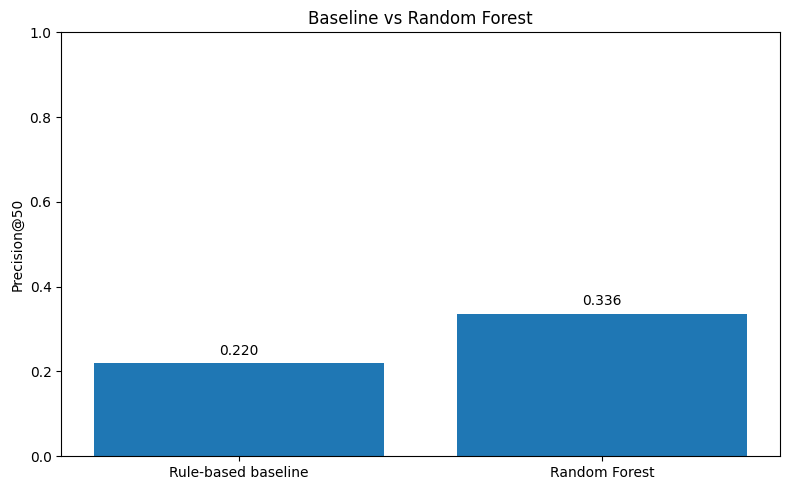

In [53]:
#  Baseline vs Random Forest chart

methods = ["Rule-based baseline", "Random Forest"]
scores = [baseline_mean, rf_mean]

plt.figure(figsize=(8, 5))
plt.bar(methods, scores)

plt.ylabel("Precision@50")
plt.title("Baseline vs Random Forest")
plt.ylim(0, 1)

for i, score in enumerate(scores):
    plt.text(i, min(score + 0.02, 0.98), f"{score:.3f}", ha="center")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "baseline_vs_random_forest.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

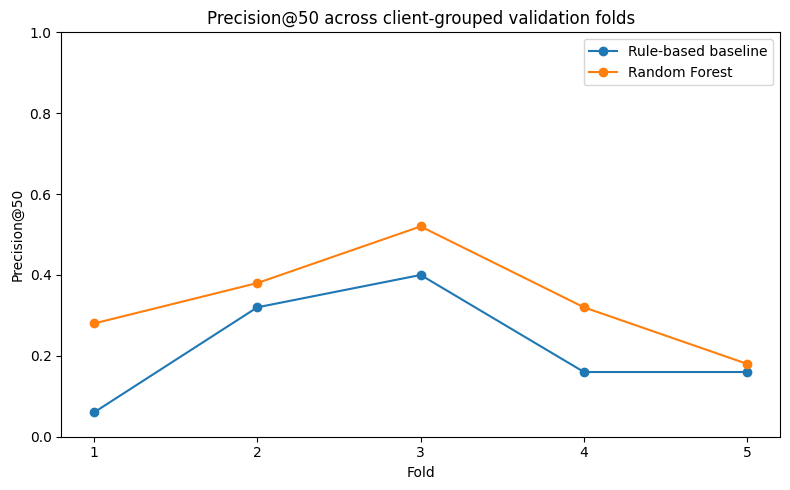

In [54]:
# Fold-level Precision@50 chart

folds = np.arange(1, N_SPLITS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    folds,
    baseline_p50s,
    marker="o",
    label="Rule-based baseline"
)

plt.plot(
    folds,
    rf_p50s,
    marker="o",
    label="Random Forest"
)

plt.xlabel("Fold")
plt.ylabel("Precision@50")
plt.title("Precision@50 across client-grouped validation folds")
plt.xticks(folds)
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

plt.savefig(
    CHART_DIR / "precision_at_50_by_fold.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

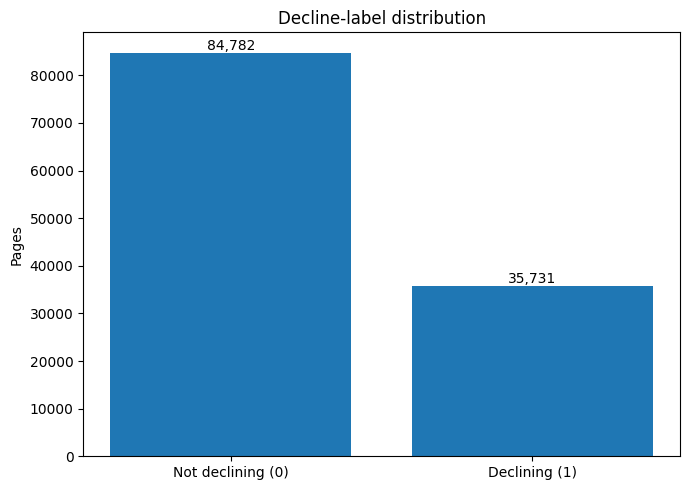

In [55]:
#  Label distribution chart

label_counts = df[TARGET].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Not declining (0)", "Declining (1)"],
    label_counts.values
)

plt.ylabel("Pages")
plt.title("Decline-label distribution")

for i, value in enumerate(label_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "label_distribution.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

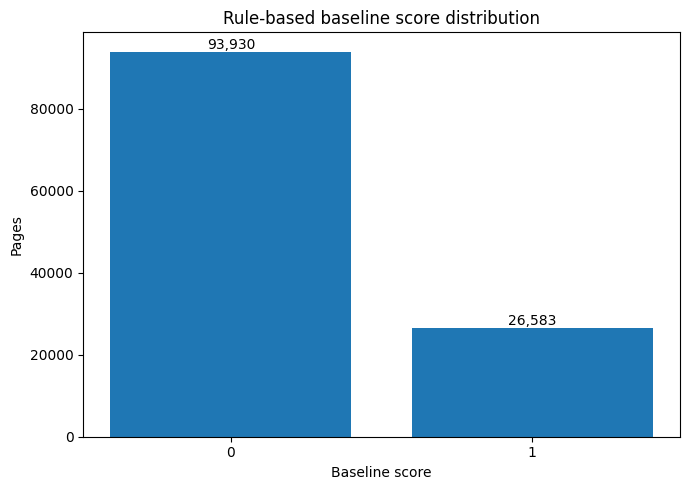

In [56]:
#  Baseline score distribution chart

baseline_counts = df["baseline_score"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    [str(x) for x in baseline_counts.index],
    baseline_counts.values
)

plt.xlabel("Baseline score")
plt.ylabel("Pages")
plt.title("Rule-based baseline score distribution")

for i, value in enumerate(baseline_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "baseline_score_distribution.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

## Model feature importance

Feature importance is descriptive, not causal. It tells us which of the three input variables the fitted Random Forest used most heavily in its splits.

It does **not** prove that a feature caused a decline.

,Feature,Importance
1,ctr,0.385020
0,avg_position,0.326212
2,impressions_feature_window,0.288768


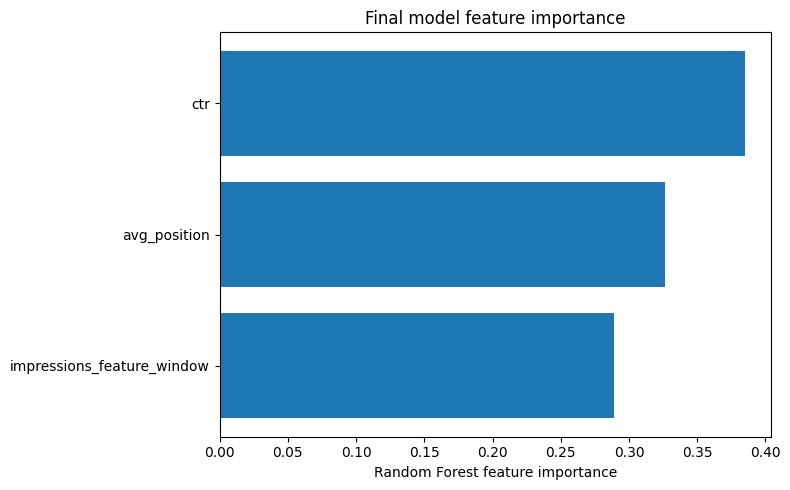

In [57]:
#  Fit final RF for ranking and feature-importance artifact

final_rf = make_rf()

final_rf.fit(
    df[FEATURES],
    df[TARGET]
)

feature_importance = (
    pd.DataFrame({
        "Feature": FEATURES,
        "Importance": final_rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

display(feature_importance)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.xlabel("Random Forest feature importance")
plt.title("Final model feature importance")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "feature_importance.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### Main Result

The Random Forest achieved Precision@50 = 0.336 ± 0.113 across five client-grouped validation folds, compared with 0.220 ± 0.123 for the selected rule-based baseline. This corresponds to an absolute improvement of +0.116 Precision@50 points.

The comparison uses the same grouped folds for both methods, so the reported difference reflects their performance under the same client-held-out evaluation design. The result is evidence about ranking performance within this experiment; it does not establish that the model will generalize to future periods or that changing the ranked pages will cause their search performance to improve.

## 5. Limitations

*What this work cannot claim.*



This experiment has several important limitations.

1. **Single time snapshot.** The evaluation uses one March 2026 feature/outcome setup. It does not establish performance on future months.

2. **Client scope.** The current scoped dataset contains 41 clients. GroupKFold prevents client overlap, but this is not a guarantee of production performance on unseen organizations.

3. **Impression floor.** The feature query requires at least 10 impressions during the feature window. Pages below that threshold cannot enter the queue. Completely dark pages are therefore invisible to this experiment.

4. **Outcome definition.** The target is based on an 80% drop in impressions, not a causal definition of content quality or refresh need.

5. **Ranking metric.** Precision@50 describes the first 50 pages. It does not tell us how the model behaves at 100, 200, or the full population.

6. **No causal interpretation.** A high model score does not mean a feature caused the decline.

7. **No automatic action.** The model does not decide what content change should be made.

8. **Freshness excluded.** `content_updated_date` was intentionally removed because the current snapshot contains future-dated values relative to the March feature window. The final model therefore does not test the potential value of freshness.

9. **Missing-position pathway is unavailable in this scope.** `avg_position_missing` is all zero in the current scoped dataset, so it is not a useful predictive feature and there is no separate "unranked" pathway in the final queue.

10. **Fold variability.** Individual client-grouped folds can differ substantially. A model average should not be interpreted as a guarantee that it beats the baseline for every client.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



### 1. Use the Random Forest to prioritize the first review pass

Rank pages by the final model score and start editorial review from the top of the queue.

The score is a prioritization signal, not a verdict.

### 2. Keep a human in the loop

For every high-ranked page, the editor should check the actual search context, content quality, intent match, freshness of the information, and whether a change is justified.

### 3. Do not auto-publish, auto-rewrite, or de-index from the model score

The model should not trigger irreversible or editorially consequential actions by itself.

### 4. Treat rule flags as supporting context

A page that matches the low-CTR baseline rule can be surfaced with that reason. A page that ranks highly without matching the rule should be treated as a **model-signal-only** case and manually reviewed.

### 5. Monitor before expanding the system

Before using the ranking operationally at larger scale, re-check the model on later time periods and inspect performance by client.

### 6. Retrain / re-check when the evidence changes

Re-evaluate when:

- Precision@50 falls below the baseline,
- client-level results become unstable,
- new clients or substantially different data are added,
- the time window moves materially forward,
- or the editorial queue definition changes.

## Ranked recommendation queue

The next cell trains the final Random Forest on the full scoped dataset **only to create the operational ranking**.

This is different from the validation result:

- **Validation score:** held-out client performance.
- **Queue score:** final model fit on all available scoped rows, used only to rank pages.

The queue score is therefore not another validation estimate.

In [58]:
# Build the ranked recommendation queue

QUEUE_SIZE = 200

queue_df = df[
    [
        "client_id",
        "content_id",
        "impressions_feature_window",
        "clicks_feature_window",
        "ctr",
        "avg_position",
        "baseline_score",
        "low_ctr_flag",
    ]
].copy()

queue_df["model_score"] = final_rf.predict_proba(
    df[FEATURES]
)[:, 1]

queue_df = queue_df.sort_values(
    ["model_score", "impressions_feature_window"],
    ascending=[False, False]
).reset_index(drop=True)

queue_df["rank"] = np.arange(1, len(queue_df) + 1)

queue_df = queue_df.head(QUEUE_SIZE).copy()

print(f"Queue size: {len(queue_df)}")
display(queue_df.head(20))

Queue size: 200


,client_id,content_id,impressions_feature_window,clicks_feature_window,ctr,avg_position,baseline_score,low_ctr_flag,model_score,rank
0,client_23a62021009f63c4,content_3ecbd0e3911c0a35,20548.0,12.0,0.058400,46.657740,0,0,0.763732,1
1,client_23a62021009f63c4,content_605169c51403d450,18845.0,6.0,0.031839,47.716780,0,0,0.763585,2
2,client_23a62021009f63c4,content_e70886c63f95aa1c,23256.0,7.0,0.030100,44.978593,0,0,0.763330,3
3,client_23a62021009f63c4,content_0b5d0ab50b14a4e0,22998.0,6.0,0.026089,44.981021,0,0,0.758001,4
4,client_23a62021009f63c4,content_ee2230ea13e45ef4,18749.0,6.0,0.032002,43.009557,0,0,0.754806,5
5,client_23a62021009f63c4,content_877c08cf2d1997a1,26514.0,13.0,0.049031,45.869447,0,0,0.752997,6
6,client_23a62021009f63c4,content_58cbfe1eec8a881e,30685.0,8.0,0.026071,46.079131,0,0,0.750180,7
7,client_23a62021009f63c4,content_54488b3c9ca74731,26353.0,9.0,0.034152,41.645825,0,0,0.748551,8
8,client_23a62021009f63c4,content_1a6829521ffd794a,17970.0,12.0,0.066778,47.890779,0,0,0.747787,9
9,client_23a62021009f63c4,content_e80f02bc33ce0922,17198.0,4.0,0.023259,42.866345,0,0,0.747116,10


## Reason codes and actions

The old notebook had freshness-dependent reason codes such as `high_traffic_stale`, `stale_and_underperforming`, `stale`, and `unranked`.

Those are removed here because freshness is not safe in the current March prediction setup, and `avg_position_missing` is zero for all scoped rows.

The final queue therefore uses only reasons supported by the current safe feature set.

In [59]:
# Assign safe reason codes and editor actions

def assign_reason(row):
    if row["low_ctr_flag"] == 1:
        return "low_ctr"
    return "model_signal_only"

def assign_action(reason):
    if reason == "low_ctr":
        return "Review title/meta and search-result presentation"
    return "Manual review of page performance, intent, and content quality"

queue_df["reason_code"] = queue_df.apply(
    assign_reason,
    axis=1
)

queue_df["recommended_action"] = queue_df["reason_code"].map(
    assign_action
)

queue_df["human_review_required"] = True
queue_df["automation_allowed"] = False

reason_summary = (
    queue_df["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="pages")
)

display(reason_summary)

display(
    queue_df[
        [
            "rank",
            "client_id",
            "content_id",
            "model_score",
            "baseline_score",
            "reason_code",
            "recommended_action",
            "human_review_required",
            "automation_allowed",
        ]
    ].head(20)
)

,reason_code,pages
0,model_signal_only,200


,rank,client_id,content_id,model_score,baseline_score,reason_code,recommended_action,human_review_required,automation_allowed
0,1,client_23a62021009f63c4,content_3ecbd0e3911c0a35,0.763732,0,model_signal_only,"Manual review of page performance, intent, and...",True,False
1,2,client_23a62021009f63c4,content_605169c51403d450,0.763585,0,model_signal_only,"Manual review of page performance, intent, and...",True,False
2,3,client_23a62021009f63c4,content_e70886c63f95aa1c,0.763330,0,model_signal_only,"Manual review of page performance, intent, and...",True,False
3,4,client_23a62021009f63c4,content_0b5d0ab50b14a4e0,0.758001,0,model_signal_only,"Manual review of page performance, intent, and...",True,False
4,5,client_23a62021009f63c4,content_ee2230ea13e45ef4,0.754806,0,model_signal_only,"Manual review of page performance, intent, and...",True,False
5,6,client_23a62021009f63c4,content_877c08cf2d1997a1,0.752997,0,model_signal_only,"Manual review of page performance, intent, and...",True,False
6,7,client_23a62021009f63c4,content_58cbfe1eec8a881e,0.750180,0,model_signal_only,"Manual review of page performance, intent, and...",True,False
7,8,client_23a62021009f63c4,content_54488b3c9ca74731,0.748551,0,model_signal_only,"Manual review of page performance, intent, and...",True,False
8,9,client_23a62021009f63c4,content_1a6829521ffd794a,0.747787,0,model_signal_only,"Manual review of page performance, intent, and...",True,False
9,10,client_23a62021009f63c4,content_e80f02bc33ce0922,0.747116,0,model_signal_only,"Manual review of page performance, intent, and...",True,False


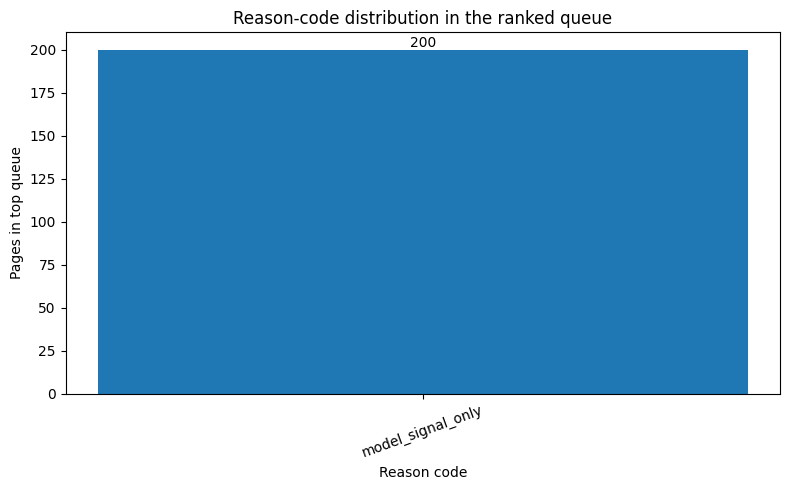

In [60]:
#  Reason-code artifact

plt.figure(figsize=(8, 5))

plt.bar(
    reason_summary["reason_code"],
    reason_summary["pages"]
)

plt.xlabel("Reason code")
plt.ylabel("Pages in top queue")
plt.title("Reason-code distribution in the ranked queue")

for i, value in enumerate(reason_summary["pages"]):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    CHART_DIR / "reason_code_distribution.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

## Human-review rules and no-go list

Every queued page requires human review.

### Mandatory review

- `reason_code == "model_signal_only"`
- all high-ranked pages before an editorial action is taken

### No-go actions

The model must **not**:

- automatically publish a rewrite,
- automatically rewrite content,
- automatically de-index a page,
- automatically delete a page,
- or score individual writers based on predictions.

The system only proposes **where to look first**.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*


This section collects the evidence the paper can show:

- main comparison table,
- fold-level comparison table,
- baseline-vs-model chart,
- fold-level Precision@50 chart,
- label distribution,
- baseline distribution,
- final-model feature importance,
- ranked queue,
- reason-code distribution,
- metrics JSON.

All artifacts are generated from the same run as the written results, so the paper does not depend on manually copied numbers.

In [61]:
# Save tables, queue, and metrics

comparison_table.to_csv(
    TABLE_DIR / "comparison_table.csv",
    index=False
)

results_df.to_csv(
    TABLE_DIR / "fold_results.csv",
    index=False
)

client_results.to_csv(
    TABLE_DIR / "client_level_validation.csv",
    index=False
)

feature_importance.to_csv(
    TABLE_DIR / "feature_importance.csv",
    index=False
)

reason_summary.to_csv(
    TABLE_DIR / "reason_code_summary.csv",
    index=False
)

queue_df.to_csv(
    ARTIFACT_DIR / "ranked_recommendation_queue.csv",
    index=False
)

metrics = {
    "feature_window": {
        "start": FEAT_START,
        "end": FEAT_END
    },
    "outcome_window_start": OUT_START,
    "rows": int(len(df)),
    "clients": int(df[GROUP_COL].nunique()),
    "pages": int(df["content_id"].nunique()),
    "declining_rate": base_rate,
    "baseline_precision_at_50_mean": baseline_mean,
    "baseline_precision_at_50_std": baseline_std,
    "random_forest_precision_at_50_mean": rf_mean,
    "random_forest_precision_at_50_std": rf_std,
    "improvement": improvement,
    "n_splits": N_SPLITS,
    "queue_size": int(len(queue_df)),
    "final_features": FEATURES,
    "impression_floor": 10,
    "human_review_required": True,
    "automation_allowed": False,
}

with open(ARTIFACT_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Artifacts written to:", ARTIFACT_DIR.resolve())

for path in sorted(ARTIFACT_DIR.rglob("*")):
    if path.is_file():
        print(path)

Artifacts written to: /content/outputs
outputs/charts/baseline_score_distribution.png
outputs/charts/baseline_vs_random_forest.png
outputs/charts/feature_importance.png
outputs/charts/label_distribution.png
outputs/charts/precision_at_50_by_fold.png
outputs/charts/reason_code_distribution.png
outputs/metrics.json
outputs/ranked_recommendation_queue.csv
outputs/tables/client_level_validation.csv
outputs/tables/comparison_table.csv
outputs/tables/feature_importance.csv
outputs/tables/fold_results.csv
outputs/tables/reason_code_summary.csv


In [62]:
#  Compact artifact preview

print("Comparison table:")
display(comparison_table)

print("\nFold results:")
display(results_df)

print("\nTop 10 recommendations:")
display(
    queue_df[
        [
            "rank",
            "client_id",
            "content_id",
            "model_score",
            "reason_code",
            "recommended_action"
        ]
    ].head(10)
)

print("\nMetrics JSON:")
print(json.dumps(metrics, indent=2))

Comparison table:


,Method,Precision@50,Std
0,Rule-based baseline,0.220000,0.122638
1,Random Forest,0.336000,0.112712
2,Base rate,0.296491,NaN



Fold results:


,Fold,Rule-based baseline,Random Forest
0,1,0.06,0.28
1,2,0.32,0.38
2,3,0.40,0.52
3,4,0.16,0.32
4,5,0.16,0.18



Top 10 recommendations:


,rank,client_id,content_id,model_score,reason_code,recommended_action
0,1,client_23a62021009f63c4,content_3ecbd0e3911c0a35,0.763732,model_signal_only,"Manual review of page performance, intent, and..."
1,2,client_23a62021009f63c4,content_605169c51403d450,0.763585,model_signal_only,"Manual review of page performance, intent, and..."
2,3,client_23a62021009f63c4,content_e70886c63f95aa1c,0.763330,model_signal_only,"Manual review of page performance, intent, and..."
3,4,client_23a62021009f63c4,content_0b5d0ab50b14a4e0,0.758001,model_signal_only,"Manual review of page performance, intent, and..."
4,5,client_23a62021009f63c4,content_ee2230ea13e45ef4,0.754806,model_signal_only,"Manual review of page performance, intent, and..."
5,6,client_23a62021009f63c4,content_877c08cf2d1997a1,0.752997,model_signal_only,"Manual review of page performance, intent, and..."
6,7,client_23a62021009f63c4,content_58cbfe1eec8a881e,0.750180,model_signal_only,"Manual review of page performance, intent, and..."
7,8,client_23a62021009f63c4,content_54488b3c9ca74731,0.748551,model_signal_only,"Manual review of page performance, intent, and..."
8,9,client_23a62021009f63c4,content_1a6829521ffd794a,0.747787,model_signal_only,"Manual review of page performance, intent, and..."
9,10,client_23a62021009f63c4,content_e80f02bc33ce0922,0.747116,model_signal_only,"Manual review of page performance, intent, and..."



Metrics JSON:
{
  "feature_window": {
    "start": "2026-03-01",
    "end": "2026-03-15"
  },
  "outcome_window_start": "2026-03-16",
  "rows": 120513,
  "clients": 41,
  "pages": 120513,
  "declining_rate": 0.29649083501365,
  "baseline_precision_at_50_mean": 0.22000000000000003,
  "baseline_precision_at_50_std": 0.12263767773404714,
  "random_forest_precision_at_50_mean": 0.336,
  "random_forest_precision_at_50_std": 0.11271202242884297,
  "improvement": 0.11599999999999999,
  "n_splits": 5,
  "queue_size": 200,
  "final_features": [
    "avg_position",
    "ctr",
    "impressions_feature_window"
  ],
  "impression_floor": 10,
  "human_review_required": true,
  "automation_allowed": false
}


### **Reproducibility**

All analysis code is available in the public repository:  
* **Repository:** [https://github.com/KinzaAsif2456/discoverey](https://github.com/KinzaAsif2456/discoverey)  
* **Notebook Path:** `work/notebooks/capstone.ipynb`

---

#### **Environment & Tech Stack**
* **Data Processing:** DuckDB (aggregates the FlyRank internship warehouse)
* **Modeling & Validation:** `scikit-learn`
* **Model Configuration:** Fixed random seed for the final Random Forest model
* **Validation Strategy:** 5-fold `GroupKFold` using `client` as the grouping variable

---

#### **Execution Instructions**
To reproduce the analysis, follow these steps:

1. Clone the repository.
2. Open `work/notebooks/capstone.ipynb` in a compatible Python or Colab environment.
3. Configure an `HF_TOKEN` secret with approved read access to the gated FlyRank internship warehouse.
4. Execute the notebook sequentially from top to bottom.

> **Note:** Credentials and raw warehouse data are omitted from the repository. Running the notebook directly regenerates all evaluation metrics, fold-level results, recommendation queues, and figures referenced in this research artifact.

### **5-Minute Demo Outline**

---

#### **0:00–0:45 — Question**
* **Problem:** Editors working across large content inventories cannot inspect every page with equal depth.
* **Question:** Can search-performance signals help prioritize pages for possible content-refresh review?

---

#### **0:45–1:30 — Data**
I used the FlyRank ML Internship warehouse and constructed page-level observations from a March 1–15, 2026 feature window. The outcome begins on March 16, 2026, and the final modeling dataset contains 120,513 page-level observations across 41 clients.

---

#### **1:30–2:30 — Method**
The final model uses three pre-outcome features: average position, CTR, and feature-window impressions. A page is labelled declining when outcome-window impressions fall below 80% of its feature-window level. The Random Forest is evaluated against a selected rule-based baseline using 5-fold `GroupKFold` by client.

---

#### **2:30–3:30 — Validation & Result**

| Model / Baseline | Precision@50 |
| :--- | :--- |
| **Random Forest** | 0.336 ± 0.113 |
| **Rule-based Baseline** | 0.220 ± 0.123 |
| **Absolute Improvement** | **+0.116 Precision@50 points** |

*The Random Forest outperformed the baseline in four of five client-grouped folds, although performance varied across folds.*

---

#### **3:30–4:15 — One Chart**
* Show the model-versus-baseline Precision@50 comparison as the main visual.
* Explain that the comparison uses the same client-grouped folds.

---

#### **4:15–5:00 — Recommendation**
Use the model as a ranked queue for human editorial review. Pages near the top should receive attention first, while editors retain responsibility for determining the appropriate action. The system does not automatically rewrite, publish, delete, or de-index content.

#  Shareable Cuts

## Social media post

I tested whether a small ML model could help editors decide which pages to check first for a possible content refresh.

Using the FlyRank internship warehouse, I built a Random Forest ranking model from pre-outcome search-performance signals and evaluated it against a rule-based baseline with client-grouped cross-validation.

The main metric was Precision@50 because the practical goal is to prioritize a short review queue.

The result is intended as decision support, not automatic content changes: a high model score means “check this sooner,” not “rewrite this page automatically.”

The full writeup and results are in my capstone paper: https://kinzaasif2456.github.io/discoverey/

## Employer-facing summary


I built a reproducible machine-learning ranking workflow to prioritize pages for potential content-refresh review using the FlyRank ML Internship warehouse. The project uses DuckDB for data aggregation, three pre-outcome search-performance features, a Random Forest model, and 5-fold client-grouped validation against a rule-based baseline. On the final scoped dataset of 120,513 page-level observations across 41 clients, the Random Forest achieved 0.336 ± 0.113 Precision@50 versus 0.220 ± 0.123 for the baseline, while the resulting recommendations remain subject to human editorial review.

In [63]:

!rm -rf discoverey
!git clone https://github.com/KinzaAsif2456/discoverey.git
!jupyter nbconvert --to html discoverey/work/notebooks/capstone.ipynb --output index.html

Cloning into 'discoverey'...
remote: Enumerating objects: 578, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 578 (delta 59), reused 6 (delta 6), pack-reused 482 (from 1)
Receiving objects: 100% (578/578), 2.62 MiB | 9.31 MiB/s, done.
Resolving deltas: 100% (373/373), done.
[NbConvertApp] Converting notebook discoverey/work/notebooks/capstone.ipynb to html
/usr/local/lib/python3.13/dist-packages/nbformat/validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  _validate(nbdict, ref, version, version_minor, relax_add_props)
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 588402 bytes to discoverey/w

In [64]:

from google.colab import files
files.download('/content/discoverey/work/notebooks/index.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#  Data Credit

Built on the **FlyRank ML Internship dataset**.

Source organization: FlyRank.

The notebook uses the internship warehouse release available through the project environment.

https://flyrank.ai/

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.